# Epstein Files Analysis

For the purpose of this project, I will be restricting my data purely to email documents.

## Identifying Emails

In [1]:
import re
import glob
from collections import defaultdict
import pandas as pd
import duckdb
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_FILES = glob.glob("../docs/TEXT/**/*.txt")

### Email Header Validation

In [3]:
REQUIRED_HEADERS = ["From:", "To:", "Sent:"]

'''
Checks if a given document is an email by checking for required headers

scan_limit used to reduce the # of lines to search for headers
'''
def isDocEmail(text: list[str], scan_limit: int = 20):
    reduced_text = text[:scan_limit]
    return all(
        any(line.strip().startswith(header) for line in reduced_text)
        for header in REQUIRED_HEADERS
    )

### Labeling Email Documents

In [4]:
EMAIL_DOCS = set()

'''
From the global DATA_FILES, find documents that are emails

Email documents are any document that contain the REQUIRED_HEADERS
'''
def findEmails():
    for file in DATA_FILES:
        with open(file, "rt", encoding="utf8") as f:
            text = f.readlines()

            if (isDocEmail(text)):
                EMAIL_DOCS.add(file)

findEmails()

### Extracting Email information

In [5]:
OPTIONAL_HEADERS = ["Subject:", "Importance:", "Attachments:"]

'''
Given a filepath to an email document, parse the email and
extract headers + content
'''
def parseEmail(filepath: str) -> defaultdict:
    with open(filepath, "rt", encoding="utf-8") as f:
        text : list[str] = f.readlines()

    data = defaultdict(str)
    last_header_loc = 0

    # Keep track of seen headers
    # Email chains wont overwrite top most header information
    seen = {h : False for h in REQUIRED_HEADERS + OPTIONAL_HEADERS}

    for i, line in enumerate(text):
        strp_line = line.strip()

        # Get all header information
        for header in REQUIRED_HEADERS + OPTIONAL_HEADERS:
            if (strp_line.startswith(header) and (not seen[header])):
                data[header[:-1]] = strp_line.removeprefix(header).strip()
                last_header_loc = max(last_header_loc, i)
                seen[header] = True
        
        # If we've seen all possible header information, stop
        if all(v for v in seen.values()):
            break
    
    body = "".join(text[last_header_loc + 1:]).strip()

    data["filename"] = filepath.split("\\")[-1]
    data["filepath"] = filepath
    data["body"] = body

    return data

### Parse Emails Into Dataframe

In [6]:
COLS = ["filename", "filepath", "body"].extend(REQUIRED_HEADERS + OPTIONAL_HEADERS)

parsed_emails = []

for doc in EMAIL_DOCS:
    data : dict = dict(parseEmail(doc))

    parsed_emails.append(data)

emails = pd.DataFrame(parsed_emails, columns=COLS)

In [15]:
# emails.to_parquet("parsed_emails.parquet")
emails

,sender,date_sent,receiver,subject,attachments,filename,filepath,body,importance,sender_email,receiver_email
0,Jeffrey Epstein,4/28/2016 4:39:12 PM,Alan M. Dershowitz ; Roy Black ; Jack Goldberger,Fwd: Reuters / lawsuit against Jeffrey Epstein,katie johnson v trump complaint.pdf,../docs/TEXT/001/HOUSE_OVERSIGHT_029837.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_029837.txt,----------Forwarded message---------- \nFrom: ...,nan,jeevacation@gmail.com,NaN
1,Richard Kahn,7/22/2015 5:29:11 PM,Jeffrey Epstein,Republicans gird for the Donald Trump debate,nan,../docs/TEXT/001/HOUSE_OVERSIGHT_024251.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_024251.txt,as you predicted.. \nhttp ://www.politico com/...,High,NaN,jeeyacation@gmail.com
2,Jeffrey Epstein,4/6/2011 10:56:35 PM,Lawrence Krauss,Re: Statement in the Daily Beast?,nan,../docs/TEXT/001/HOUSE_OVERSIGHT_031074.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_031074.txt,what evidence? no real sex.. where is she gett...,nan,jeeyacation@gmail.com,NaN
3,Jeffrey Epstein,4/22/2015 7:16:34 PM,Darren lndyke,Fwd: ATTORNEY-CLIENT PRIVILEGE,nan,../docs/TEXT/001/HOUSE_OVERSIGHT_022926.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_022926.txt,----------Forwarded message---------- \nFrom: ...,High,jeeyacation@gmail.com,NaN
4,Jeffrey Epstein,9/12/2018 6:15:20 PM,Larry Summers,Re: This morning,nan,../docs/TEXT/001/HOUSE_OVERSIGHT_026508.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_026508.txt,https://www.cato-unbound.org/2016/12/13/jason-...,nan,jeeyacation@gmail.com,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2142,Barbro Ehnbom,1/20/2017 10:55:49 PM,,"January 20, 2017",DSC_0192.JPG; DSC_0192.JPG,../docs/TEXT/001/HOUSE_OVERSIGHT_031189.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_031189.txt,"Dearest Jeffrey, \nHAPPY HAPPY HAPPY HAPPY!!! ...",High,NaN,jeevacation@gmail.com
2143,Jeffrey Epstein,10/30/2014 2:50:38 AM,Nil Priell Barak,Re:,nan,../docs/TEXT/002/HOUSE_OVERSIGHT_032162.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032162.txt,begining edits \nDavid Ben Gurion was asked wh...,nan,jeeyacation@gmail.com,NaN
2144,Kathy Ruemmler,1/4/2018 6:10:55 PM,Jeffrey Epstein,Re:,nan,../docs/TEXT/002/HOUSE_OVERSIGHT_032707.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032707.txt,"Finally got the apartment so can ""move in"" tom...",High,NaN,jeeyacation@gmail.com
2145,,,,,,../docs/TEXT/001/HOUSE_OVERSIGHT_030516.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_030516.txt,Jeffrey Epstein [jeeyacation@gmail.com] \n3/7/...,nan,NaN,NaN


# Cleaning Data

Now that the data has been parsed, we have to clean it.

For example, dates are in multiple formats. Info has been redacted, so it is missing. etc.

### Consistent Case

In [7]:
emails.columns  # I messed up, column names are mixed case

def cleanColumnCase():
    emails.columns = [col.strip().lower() for col in emails.columns]

    # Remove whitespace 
    for col in emails.columns:
        emails[col] = emails[col].astype(str).str.strip()

emails.columns

Index(['From', 'Sent', 'To', 'Subject', 'filename', 'filepath', 'body',
       'Importance', 'Attachments'],
      dtype='object')

### Renaming Column Names

In [8]:
def renameColumns():
    emails.rename(columns={"from": "sender", 
                        "sent": "date_sent", 
                        "to": "receiver"},
                inplace=True)

emails.columns

Index(['From', 'Sent', 'To', 'Subject', 'filename', 'filepath', 'body',
       'Importance', 'Attachments'],
      dtype='object')

### Extracting Emails From Header

In [9]:
cleanColumnCase()
renameColumns()
# Stole this from Google
email_pattern = r"([a-zA-Z0-9._%+\-\s]+[\@|\©][a-zA-Z0-9.\-\s]+\.[a-zA-Z]{2,})" # .extract wanted the pattern surrounded in ()
sr_pattern = r"[a-zA-Z0-9._%+\-\s]+@[a-zA-Z0-9.\-\s]+\.[a-zA-Z]{2,}"

# Extracting emails
emails["sender_email"] = emails["sender"].str.extract(email_pattern, expand=False)
emails["receiver_email"] = emails["receiver"].str.extract(email_pattern, expand=False)

# Removing emails from original columns
emails["sender"] = emails["sender"].str.replace(sr_pattern, "", regex=True).str.strip()
emails["receiver"] = emails["receiver"].str.replace(sr_pattern, "", regex=True).str.strip()

# Cleanup leftover (Note: This still doesn't take care of everything)
emails["sender"] = emails["sender"].str.replace(r"[\[\]]|[\<\>]", "", regex=True).str.strip()
emails["receiver"] = emails["receiver"].str.replace(r"[\[\]]|[\<\>]|[\(\)]", "", regex=True).str.strip()

### Cleaning Epstein Name Variations

In [10]:
candidates = set(
    [x for x in emails["sender"].unique() if isinstance(x, str) and ("jee" in x or "jeff" in x)] 
    + [x for x in emails["receiver"].unique() if isinstance(x, str) and ("jee" in x or "jeff" in x)]
)

candidates.add("Jeffrey Epstein jeevacation©gmail.com")
candidates.add("J")
candidates.add("j")

sorted(candidates)

def clean_epstein_names(name: str):
    if name.strip() in candidates:
        return "Jeffrey Epstein"
    else:
        return name
    
emails["sender"] = emails["sender"].apply(clean_epstein_names)
emails["receiver"] = emails["receiver"].apply(clean_epstein_names)

In [11]:
def remove_underscores(name: str):
    return name.strip("_")

emails["sender"] = emails["sender"].apply(remove_underscores)
emails["receiver"] = emails["receiver"].apply(remove_underscores)

In [14]:
emails["receiver_email"].unique()

array([nan, 'jeeyacation@gmail.com', 'jeevacation@gmail.com',
       'gmax1@ellmax.com', 'jjepjeevacation@gmail.com', 'owlmgw@att.net',
       'jdeevacation@gmail.com', 'eeyacation@gmail.com',
       'jeffreyepsteinjeevacation@gmail.com', 'jeeproject@yahoo.com',
       'jeffreyepsteinpeeyacation@gmail.com',
       'jeffreye.peeyacation@gmail.com',
       'darrenindykejeeyacation@gmail.com'], dtype=object)

### Cleaning Emails

In [13]:
def clean_email(text: str):
    if (not isinstance(text, str)):
        return text
    
    text = text.strip().lower()
    
    # "mailto" is an HTML action that opens the user's default email client when clicked
    text = text.replace("mailto:", "")

    # Remove whitespace from emails
    text = text.replace(" ", "")

    # Replace © with @
    text = text.replace("©", "@")

    # Replace common misspellings of "gmail"
    text = text.replace("@grnail", "@gmail")
    text = text.replace("@gmaii", "@gmail")
    text = text.replace("@mail", "@gmail")
    

    # Replace common mispellings of ".com"
    text = text.replace(".comi", ".com")
    text = text.replace(".corn", ".com")

    return text.strip()
    
emails["sender_email"] = emails["sender_email"].apply(clean_email)
emails["receiver_email"] = emails["receiver_email"].apply(clean_email)

emails

,sender,date_sent,receiver,subject,filename,filepath,body,importance,attachments,sender_email,receiver_email
0,Jeffrey Epstein,10/31/2011 10:50:46 AM,Katherine Keating,Re: After Words,../docs/TEXT/001/HOUSE_OVERSIGHT_029663.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_029663.txt,"where are you? \nOn Mon, Oct 31, 2011 at 4:21 ...",nan,nan,jeeyacation@gmail.com,NaN
1,Jeffrey Epstein,3/24/2018 1:16:30 PM,Kathy Ruemmler,Re:,../docs/TEXT/002/HOUSE_OVERSIGHT_033082.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_033082.txt,"i was kidding \nOn Sat, Mar 24, 2018 at 9:14 A...",High,nan,jeeyacation@gmail.com,NaN
2,,,,,../docs/TEXT/001/HOUSE_OVERSIGHT_029590.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_029590.txt,"Jeffrey, \nHow's this \nOn Sun, Nov 25, 2018 a...",High,,NaN,NaN
3,Kathy Ruemmler,2/24/2018 3:36:08 AM,,Lawyer for Susan Rice: Obama administration 'j...,../docs/TEXT/001/HOUSE_OVERSIGHT_026787.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_026787.txt,https://www.politico.com/story/2018/02/23/susa...,High,nan,NaN,jeeyacation@gmail.com
4,Richard Kahn,11/30/2017 10:28:42 AM,Jeffrey Epstein,Trump 'made comment about p**sy years before t...,../docs/TEXT/002/HOUSE_OVERSIGHT_033260.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_033260.txt,http://www.dailymail.co.uk/news/article-513117...,High,nan,NaN,jeeyacation@gmail.com
...,...,...,...,...,...,...,...,...,...,...,...
2142,"Thomas Jr., Landor",9/16/2016 8:07:51 PM,Jeffrey Epstein,Re: Trump,../docs/TEXT/002/HOUSE_OVERSIGHT_032285.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032285.txt,"you think he will win? \nOn Fri, Sep 16, 2016 ...",High,nan,NaN,jeeyacation@gmail.com
2143,Kathy Ruemmler,1/24/2017 4:21:55 PM,Jeffrey Epstein,Fwd: Press: Heatstreat- 'Shady' Israeli Mogul ...,../docs/TEXT/001/HOUSE_OVERSIGHT_026652.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_026652.txt,Look at this craziness. \nBegin forwarded mess...,High,image001.jpg; image005.jpg; image004.jpg; imag...,NaN,jeeyacation@gmail.com
2144,Kathy Ruemmler,2/15/2017 1:28:39 PM,Jeffrey Epstein,Re:,../docs/TEXT/002/HOUSE_OVERSIGHT_032472.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032472.txt,"Yes, of course. \nSent from my iPad \nOn Feb 1...",High,nan,NaN,jeeyacation@gmail.com
2145,Boris Nikolic,5/7/2012 11:27:15 PM,Jeffrey Epstein,FW: Zeitplan amfar Gala 19.5.2012,../docs/TEXT/001/HOUSE_OVERSIGHT_028768.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_028768.txt,Eva is my friend there who will host us. She i...,nan,nan,NaN,jeevacation@gmail.com


## Who Was Epstein Emailing?

In [43]:
query = f"""
    SELECT
        receiver
    FROM
        emails
"""
duckdb.query(query).df()

,receiver
0,Jeffrey Epstein
1,Jeffrey Epstein
2,Peggy Siegal
3,Jeffrey Epstein
4,
...,...
2142,Steve Bannon
2143,Ken Starr
2144,Jeffrey Epstein
2145,Jeffrey Epstein


In [42]:
target = "Michael"
query = f"""
    SELECT
        DISTINCT receiver
    FROM
        emails
    WHERE
        receiver ILIKE '%{target}%'
"""
duckdb.query(query).df()

,receiver
0,Michael Wolff
1,Michael S. Buchholtz
2,Michael S. Sitrick
3,DANNY GOLDBERG ; Sam/Walli Leff Michael Simmons
4,Michael J. Pike


In [15]:
## Let's first fix some names
NAME_MAPPING = {
    "Jeffrey Epstein": ["jeffrey E.", "jeffrey E. peevacationPgmail.coml", "'jeffrey E.'", "Jeffrey", "effrey E. jeeyacation@gmail,com",
                        "Jeffrey Epstein ; Jeffrey Epstein", "Jeffrey", "Jeffrey Epstein  ;", "jeffrey E. ;", "Jefffrey Epstein"],
    "Michael Wolff": ["Michael Wolff___________________________________", "Michael Wolff _________________________________1",
                      "Michael Wolff________________________________", "Michael Wolff__________________________________",
                      "Michael Woli"],
    "Thomas Landon": ["Thomas Jr., Landon___________________________", "Thomas Jr., Landon'", "Landon Thomas Jr",
                      "Landon Thomas Jr.", "Thomas Jr., Landon________________", "Landon Thomas", "Thomas Jr., Landon"],
    "Kathy Ruemmler": ["Kathy Ruemmlerl", "Kathy Ruemmler ______________________________", "Kathy Ruemmler _______________________________",
                       "Kathy Ruemmler I", "Kathy", "Kathy Ruemmler__________________", "Kathy Ruemmler f"],
    "Richard Kahn": ["Richard Kahn_________________________________", "Richard Kahn______________________________", 
                     "Richard Kahn_______________________"],
    "Ghislaine Maxwell": ["Gmax", "G Maxwell"]
}

REVERSED_NAME_MAPPING = {x: k for k,v in NAME_MAPPING.items() for x in v}

def applyNameMapping(name: str):
    if (not isinstance(name, str)):
        return None
    
    name = name.strip()

    try:
        return REVERSED_NAME_MAPPING[name]
    except KeyError:
        return name
emails["sender"] = emails["sender"].apply(applyNameMapping)
emails["receiver"] = emails["receiver"].apply(applyNameMapping)

In [45]:
# emails["receiver_list"] = emails["receiver"].str.split(":")
# receiver_exploded = emails.explode("receiver_list")
# receiver_exploded["receiver_list"] = receiver_exploded["receiver_list"].str.strip()
# receiver_exploded = receiver_exploded[receiver_exploded["receiver_list"] != ""]

candidate_emails = [e for e in emails["sender_email"].unique() if isinstance(e, str) and ("jee" in e)]

epstein_alias = [p for p in emails["sender"].unique() if isinstance(p, str) and ("jef" in p.lower() or "epst" in p.lower() or "jee" in p.lower())]

epstein_receivers = emails[emails["sender"].isin(epstein_alias)]["receiver"]

epstein_receivers = epstein_receivers.dropna().to_frame()

C:\Users\Connor\AppData\Local\Temp\ipykernel_44436\4027095566.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


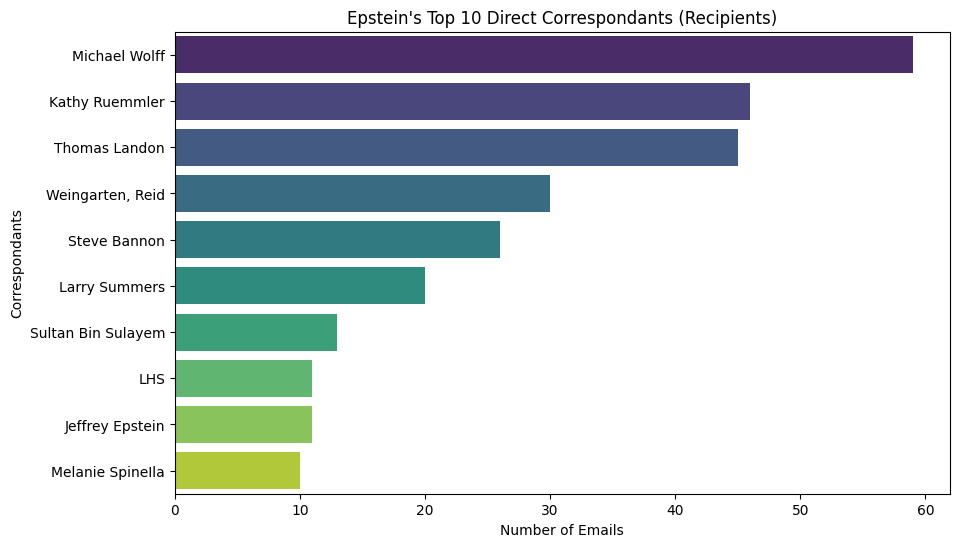

,receiver,freq
0,Michael Wolff,59
1,Kathy Ruemmler,46
2,Thomas Landon,45
3,"Weingarten, Reid",30
4,Steve Bannon,26
5,Larry Summers,20
6,Sultan Bin Sulayem,13
7,LHS,11
8,Jeffrey Epstein,11
9,Melanie SpineIla,10


In [46]:
query = f"""
    SELECT
        receiver,
        COUNT(*) AS freq
    FROM
        epstein_receivers
    WHERE
        length(receiver) > 0
    GROUP BY
        receiver
    ORDER BY
        freq DESC
    LIMIT 10
"""
epstein_contacts = duckdb.query(query).df()

plt.figure(figsize=(10, 6))
bars = sns.barplot(
    x=epstein_contacts["freq"],
    y=epstein_contacts["receiver"],
    palette="viridis"
)

plt.title("Epstein's Top 10 Direct Correspondants (Recipients)")
plt.xlabel("Number of Emails")
plt.ylabel("Correspondants")
plt.show()

epstein_contacts

## Who Was Emailing Epstein?

In [47]:
epstein_alias = [p for p in emails["receiver"].unique() if isinstance(p, str) and ("je" in p.lower() or "eps" in p.lower())]

epstein_senders = emails[emails["receiver"].isin(epstein_alias)]["sender"]

epstein_senders = epstein_senders.dropna().to_frame()

C:\Users\Connor\AppData\Local\Temp\ipykernel_44436\2700905116.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


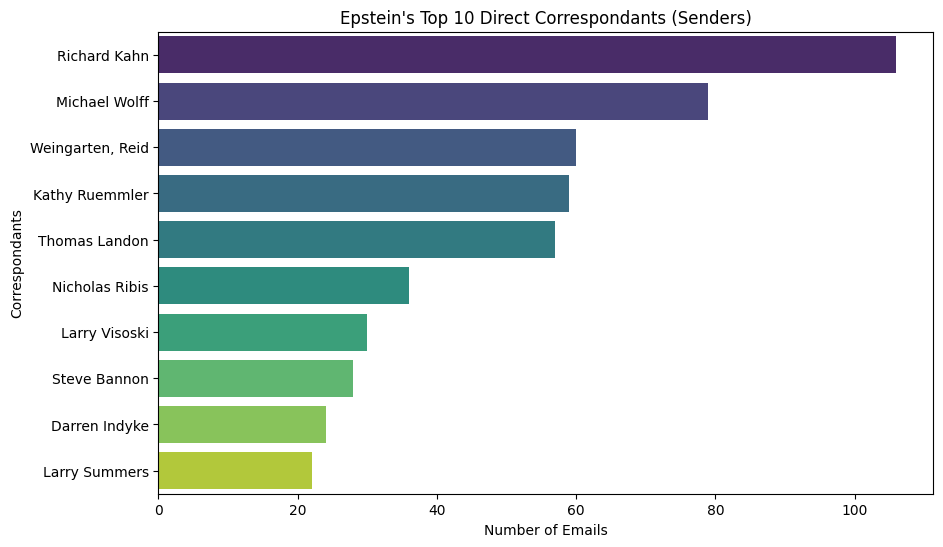

In [48]:
query = f"""
    SELECT
        sender,
        COUNT(*) AS freq
    FROM
        epstein_senders
    WHERE
        length(sender) > 1
    GROUP BY
        sender
    ORDER BY
        freq DESC
    LIMIT 10
"""

epstein_contacts = duckdb.query(query).df()

plt.figure(figsize=(10, 6))
bars = sns.barplot(
    x=epstein_contacts["freq"],
    y=epstein_contacts["sender"],
    palette="viridis"
)

plt.title("Epstein's Top 10 Direct Correspondants (Senders)")
plt.xlabel("Number of Emails")
plt.ylabel("Correspondants")
plt.show()

# Distribution of Email Lengths

C:\Users\Connor\AppData\Local\Temp\ipykernel_44436\1890350526.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(emails_lengths_log, bins=50, palette="viridis", kde=True)


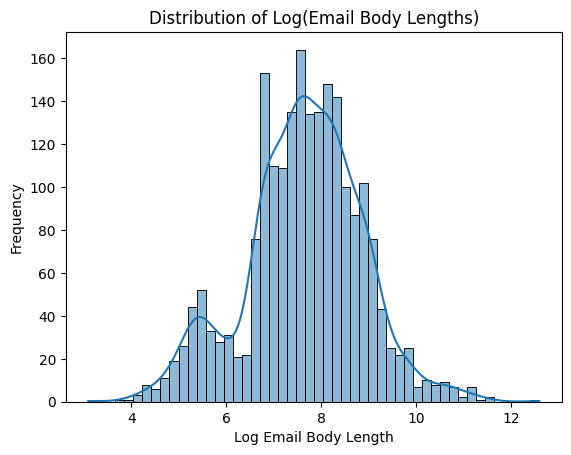

In [89]:
email_lengths = emails["body"].str.len()
emails_lengths_log = np.log(email_lengths)

sns.histplot(emails_lengths_log, bins=50, palette="viridis", kde=True)
plt.xlabel("Log Email Body Length")
plt.ylabel("Frequency")
plt.title("Distribution of Log(Email Body Lengths)")
plt.show()

## Michael Wolff

In [ ]:
target = "Noam Chomsky"
emails[((emails["sender"] == target) | (emails["receiver"] == target))]["filepath"]

1077    ../docs/TEXT\002\HOUSE_OVERSIGHT_032633.txt
1158    ../docs/TEXT\002\HOUSE_OVERSIGHT_033043.txt
Name: filepath, dtype: object

In [26]:
emails["dt"] = pd.to_datetime(emails["date_sent"], errors="coerce")
emails["month"] = pd.to_datetime(emails["dt"].dt.to_period("M"), errors="coerce")

emails

/var/folders/ml/fzp4hsz17tb4xtns43992l0w0000gn/T/ipykernel_55970/738025596.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  emails["dt"] = pd.to_datetime(emails["date_sent"], errors="coerce")


,sender,date_sent,receiver,subject,importance,filename,filepath,body,attachments,sender_email,receiver_email,dt,month
0,Richard Kahn,11/14/2016 3:04:29 PM,Jeffrey Epstein,aapl,High,../docs/TEXT/002/HOUSE_OVERSIGHT_033192.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_033192.txt,http://www.cnbc.com/2016/11/14/apple-iphones-c...,nan,NaN,jeeyacation@gmail.com,2016-11-14 15:04:29,NaT
1,anasalrasheed,11/6/2017 9:07:51 PM,Jeffrey Epstein,Re:,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032643.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032643.txt,this was just tweeted by famous saudi oppositi...,nan,NaN,jeeyacation@gmail.com,2017-11-06 21:07:51,NaT
2,,1/15/2017 1:49:11 PM,Jeffrey Epstein,Re:,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032436.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032436.txt,People are just back and the activity really s...,nan,NaN,jeeyacation@gmail.com,2017-01-15 13:49:11,NaT
3,,12/22/2017 12:23:04 PM,Jeffrey Epstein,Re:,High,../docs/TEXT/001/HOUSE_OVERSIGHT_026237.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_026237.txt,very well .. keep us posted about your gee tri...,nan,NaN,jeeyacation@gmail.com,2017-12-22 12:23:04,NaT
4,Thorbjon Jagland,4/16/2017 3:23:31 PM,Jeffrey Epstein,Re:,High,../docs/TEXT/001/HOUSE_OVERSIGHT_026673.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_026673.txt,You should feel well for having done so much f...,nan,NaN,jeeyacation@gmail.com,2017-04-16 15:23:31,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2142,Nicholas Ribis,5/13/2016 12:31:13 AM,Jeffrey Epstein,Fw: Washington Post Article,High,../docs/TEXT/002/HOUSE_OVERSIGHT_033295.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_033295.txt,Sent from my BlackBerry 10 smartphone. \nThoug...,nan,NaN,jeeyacation@gmail.com,2016-05-13 00:31:13,NaT
2143,Linda Stone__________________________,11/13/2016 6:34:38 PM,Jeffrey Epstein,Re: My sister's perspective from Europe,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032363.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032363.txt,Putin? NATO? Those were the points my sister r...,nan,NaN,jeevacation@gmail.com,2016-11-13 18:34:38,NaT
2144,"Weingarten, Reid",11/2/2017 6:05:42 PM,Jeffrey Epstein,Re:,High,../docs/TEXT/001/HOUSE_OVERSIGHT_030666.txt,../docs/TEXT/001/HOUSE_OVERSIGHT_030666.txt,Yep...order rod to fire him...rod would refuse...,nan,NaN,jeeyacation@gmail.com,2017-11-02 18:05:42,NaT
2145,Kathy Ruemmler,1/21/2016 2:42:21 AM,Jeffrey Epstein,Re: Meet?,High,../docs/TEXT/002/HOUSE_OVERSIGHT_032233.txt,../docs/TEXT/002/HOUSE_OVERSIGHT_032233.txt,Privileged - Redacted \nSent from my iPhone \n...,nan,NaN,jeeyacation@gmail.com,2016-01-21 02:42:21,NaT


In [ ]:
query=f"""
    SELECT
        receiver,
        CAST(dt AS DATE) AS date,
        COUNT(*) AS freq
    FROM
        emails
    WHERE
        length(emails.receiver) > 1 AND length(emails.sender) > 1
    GROUP BY
        receiver, dt
    ORDER BY
        receiver, dt ASC
"""

duckdb.query(query).df().to_csv("")

,receiver,dt,freq
0,'',2012-01-23,1
1,'',2012-10-16,1
2,'' ;,2011-03-08,1
3,'Jeffrey Epstein',2011-06-27,1
4,'Jeffrey Epstein',2011-08-07,1
...,...,...,...
1448,soon yi previn,2015-12-08,1
1449,soon yi previn,2016-05-04,1
1450,soon yi previn,2017-06-30,1
1451,• Darren Indyke,2013-05-13,1


# Connecting People

In [16]:
import networkx as nx
from pyvis.network import Network
import spacy

In [17]:
nlp = spacy.load("en_core_web_sm")

def get_entities(text: str):
    doc = nlp(text)

    ent_names = []
    for ent in doc.ents:
        # print(f"{ent.text} {ent.start_char} {ent.end_char} {ent.label_}")
        if (ent.label_ == "PERSON" or ent.label_ == "ORG"):
            if (ent.text and len(ent.text) > 1):
                ent_names.append(ent.text)
        
    return ent_names

In [18]:
G = nx.DiGraph()

for _, row in emails.iterrows():
    sender = row["sender"]
    receiver = row["receiver"]

    entities = get_entities(row["body"])

    if (pd.notna(sender) and pd.notna(receiver)):
        if (len(sender) < 3 or len(receiver) < 3):
            continue

        if G.has_edge(sender, receiver):
            G[sender][receiver]["weight"] += 1
        else:
            G.add_edge(sender, receiver, weight=1)
    
    # Weight entities less since not a direct connection (1/10)
    if (len(entities) > 0):
        # Remove sender and receiver from entities
        entities = set(entities) - set([sender, receiver])
        for ent in entities:
            if G.has_edge(sender, ent):
                G[sender][ent]["weight"] += 0.1
            else:
                G.add_edge(sender, ent, weight=1)

            if G.has_edge(receiver, ent):
                G[receiver][ent]["weight"] += 0.1
            else:
                G.add_edge(receiver, ent, weight=0.1)

print("Total Nodes:", G.number_of_nodes())
print("Total Edges:", G.number_of_edges())

pos = nx.spring_layout(G)
net = Network(notebook=True, directed=True, height="1000px", width="100%")
for node in G.nodes():
    x, y = pos[node]
    net.add_node(node, label=node, x=x*1000, y=y*1000, physics=False)

for u, v, d in G.edges(data=True):
    net.add_edge(u, v, value=d["weight"], physics=False)
net.show("email_network_entire.html")

Total Nodes: 9183
Total Edges: 25427
email_network_entire.html


In [19]:
largest_scc = max(nx.strongly_connected_components(G), key=len)
G_scc = G.subgraph(largest_scc).copy()

print("Largest strongly connected component size:", len(G_scc.nodes()))

degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, normalized=True)

eigenvector_centrality = nx.eigenvector_centrality_numpy(G_scc)

centrality_df = pd.DataFrame({
    "degree": degree_centrality,
    "betweenness": betweenness_centrality
})

centrality_df["eigenvector"] = centrality_df.index.map(eigenvector_centrality)

pos = nx.spring_layout(G_scc)
net = Network(notebook=True, directed=True, height="1000px", width="100%")
net.toggle_physics(False)

for node in G_scc.nodes():
    x, y = pos[node]
    net.add_node(node, label=node, x=x*1000, y=y*1000)

for u, v, d in G_scc.edges(data=True):
    net.add_edge(u, v, value=d["weight"])
net.show("email_network_scc.html")

centrality_df.sort_values("eigenvector", ascending=False).head(10)

Largest strongly connected component size: 172
email_network_scc.html


,degree,betweenness,eigenvector
Jeffrey Epstein,0.916685,0.026553,0.638414
Ghislaine Maxwell,0.004792,0.000352,0.150319
Alan Dershowitz,0.024722,0.000430,0.122968
Martin Weinberg,0.018514,0.000262,0.117505
Jack Goldberger,0.009366,0.000282,0.116083
Martin G. Weinberg,0.006970,0.000350,0.108745
Jeffrey E.,0.002287,0.000054,0.103868
Darren Indyke,0.038989,0.000413,0.103819
Steve Bannon,0.044761,0.000120,0.100638
Michael Wolff,0.035069,0.000043,0.100495
